<a href="https://colab.research.google.com/github/misbahhassan6400/flyrank-ml-internship/blob/main/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

This playbook ranks February 2026 client-content rows for human review. It uses only observed February Search Console and GA4 signals.

Reason codes:

- `CTR_FIX`: top-ten average position with low CTR and enough impressions. Action: review title and snippet.
- `DECAY_REFRESH`: impressions declined from the first half to the second half of February. Action: inspect freshness and content changes.
- `QUICK_WIN_VOLUME`: high impressions with average position 11 to 20. Action: review for an achievable ranking improvement.
- `LOW_DATA`: too little volume or missing position data. Action: collect more evidence before acting.
- `MONITOR`: no priority rule matched.

The score is a directional prioritization score, not predicted revenue or guaranteed impact.

In [ ]:
!pip -q install duckdb huggingface_hub pandas scikit-learn scipy

import duckdb
import pandas as pd
import numpy as np
import json
import os

from google.colab import userdata

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

HF_TOKEN = userdata.get("HF_TOKEN")
if not HF_TOKEN:
    raise ValueError("HF_TOKEN missing. Colab Secrets mein access ON karo.")

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
)
""")

files = con.sql("""
SELECT file
FROM glob('hf://datasets/FlyRank/internship-warehouse/**/*.parquet')
""").df()

feb_matches = files[
    files["file"].astype(str).str.contains("2026-02", regex=False)
]

mar_matches = files[
    files["file"].astype(str).str.contains("2026-03", regex=False)
]

FEB = feb_matches.iloc[0]["file"]
MAR = mar_matches.iloc[0]["file"]

print("Setup complete")
print("FEB:", FEB)
print("MAR:", MAR)

Setup complete
FEB: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/data_0.parquet
MAR: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet


In [ ]:
import os
import json
import numpy as np
import pandas as pd

# February-only feature frame
playbook_df = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,

    COALESCE(
        SUM(gsc_impressions)
        FILTER (WHERE gsc_data_available IS TRUE),
        0
    ) AS gsc_impressions,

    COALESCE(
        SUM(gsc_clicks)
        FILTER (WHERE gsc_data_available IS TRUE),
        0
    ) AS gsc_clicks,

    AVG(gsc_avg_position)
        FILTER (
            WHERE gsc_data_available IS TRUE
            AND gsc_avg_position IS NOT NULL
        ) AS gsc_avg_position,

    COALESCE(
        SUM(gsc_impressions)
        FILTER (
            WHERE gsc_data_available IS TRUE
            AND report_date <= DATE '2026-02-14'
        ),
        0
    ) AS early_impressions,

    COALESCE(
        SUM(gsc_impressions)
        FILTER (
            WHERE gsc_data_available IS TRUE
            AND report_date >= DATE '2026-02-15'
        ),
        0
    ) AS late_impressions

FROM read_parquet('{FEB}')
WHERE month = '2026-02'
GROUP BY client_hash_id, content_hash_id
""").df()

playbook_df["ctr"] = np.where(
    playbook_df["gsc_impressions"] > 0,
    playbook_df["gsc_clicks"] / playbook_df["gsc_impressions"],
    np.nan
)

playbook_df["decay_rate"] = np.where(
    playbook_df["early_impressions"] > 0,
    (
        playbook_df["late_impressions"]
        - playbook_df["early_impressions"]
    ) / playbook_df["early_impressions"],
    np.nan
)

playbook_df["reason_code"] = np.select(
    [
        (
            (playbook_df["gsc_avg_position"] <= 10)
            & (playbook_df["ctr"] < 0.02)
            & (playbook_df["gsc_impressions"] >= 100)
        ),
        (
            (playbook_df["decay_rate"] <= -0.30)
            & (playbook_df["early_impressions"] >= 100)
        ),
        (
            (playbook_df["gsc_impressions"] >= 1000)
            & (playbook_df["gsc_avg_position"] > 10)
            & (playbook_df["gsc_avg_position"] <= 20)
        ),
        (
            (playbook_df["gsc_impressions"] < 100)
            | (playbook_df["gsc_avg_position"].isna())
        )
    ],
    [
        "CTR_FIX",
        "DECAY_REFRESH",
        "QUICK_WIN_VOLUME",
        "LOW_DATA"
    ],
    default="MONITOR"
)

playbook_df["action_label"] = playbook_df["reason_code"].map({
    "CTR_FIX": "Review title and snippet",
    "DECAY_REFRESH": "Inspect freshness and refresh content",
    "QUICK_WIN_VOLUME": "Review for ranking improvement",
    "LOW_DATA": "Collect more evidence",
    "MONITOR": "Monitor"
})

playbook_df["score"] = np.select(
    [
        playbook_df["reason_code"] == "CTR_FIX",
        playbook_df["reason_code"] == "DECAY_REFRESH",
        playbook_df["reason_code"] == "QUICK_WIN_VOLUME",
        playbook_df["reason_code"] == "LOW_DATA"
    ],
    [
        100 + np.minimum(30, np.log1p(playbook_df["gsc_impressions"])),
        85 + np.minimum(25, np.log1p(playbook_df["early_impressions"])),
        60 + np.minimum(30, np.log1p(playbook_df["gsc_impressions"])),
        5
    ],
    default=20 + np.minimum(10, np.log1p(playbook_df["gsc_impressions"]))
)

playbook_df["review_effort"] = playbook_df["reason_code"].map({
    "CTR_FIX": "medium",
    "DECAY_REFRESH": "high",
    "QUICK_WIN_VOLUME": "medium",
    "LOW_DATA": "low",
    "MONITOR": "low"
})

# This is only an attention/value proxy, not revenue
playbook_df["volume_value_proxy"] = np.log1p(
    playbook_df["gsc_impressions"]
)

queue = playbook_df.sort_values(
    ["score", "gsc_impressions"],
    ascending=[False, False]
).reset_index(drop=True)

queue.insert(0, "rank", np.arange(1, len(queue) + 1))

queue_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "score",
    "reason_code",
    "action_label",
    "review_effort",
    "volume_value_proxy",
    "gsc_impressions",
    "gsc_clicks",
    "ctr",
    "gsc_avg_position",
    "decay_rate"
]

queue = queue[queue_columns]

print("Queue rows:", len(queue))
display(queue.head(10))
display(queue["reason_code"].value_counts().to_frame("n"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Queue rows: 321546


,rank,client_hash_id,content_hash_id,score,reason_code,action_label,review_effort,volume_value_proxy,gsc_impressions,gsc_clicks,ctr,gsc_avg_position,decay_rate
0,1,client_73cda7b4e4f265ea,content_8e1334d6356668e3,112.222940,CTR_FIX,Review title and snippet,medium,12.222940,203401.0,2.0,0.000010,4.967059,18.471115
1,2,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,112.184078,CTR_FIX,Review title and snippet,medium,12.184078,195648.0,1.0,0.000005,2.488437,85.734529
2,3,client_73cda7b4e4f265ea,content_fec55986a1868d62,112.175381,CTR_FIX,Review title and snippet,medium,12.175381,193954.0,0.0,0.000000,3.844678,12.972518
3,4,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,112.027568,CTR_FIX,Review title and snippet,medium,12.027568,167303.0,3310.0,0.019784,2.923168,-0.093522
4,5,client_73cda7b4e4f265ea,content_e241d6415ac9e534,112.008554,CTR_FIX,Review title and snippet,medium,12.008554,164152.0,401.0,0.002443,2.925926,-0.207282
5,6,client_62f4a7e64f5e0096,content_b99ea6861864dea5,111.987295,CTR_FIX,Review title and snippet,medium,11.987295,160699.0,273.0,0.001699,3.715542,-0.121863
6,7,client_62f4a7e64f5e0096,content_f107e54b10b43725,111.958662,CTR_FIX,Review title and snippet,medium,11.958662,156163.0,883.0,0.005654,3.095657,0.122385
7,8,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,111.947969,CTR_FIX,Review title and snippet,medium,11.947969,154502.0,2508.0,0.016233,4.240872,0.136632
8,9,client_62f4a7e64f5e0096,content_acbcc847f8996314,111.906703,CTR_FIX,Review title and snippet,medium,11.906703,148256.0,239.0,0.001612,3.907896,0.162522
9,10,client_e547b89c05043229,content_c9a0c2fdbdbfb562,111.865102,CTR_FIX,Review title and snippet,medium,11.865102,142215.0,1605.0,0.011286,1.882000,-0.329790


,n
reason_code,
LOW_DATA,241224
CTR_FIX,51626
MONITOR,19886
QUICK_WIN_VOLUME,4822
DECAY_REFRESH,3988


## 2. Intended use and limits

The content or SEO team can use this queue to decide which anonymized content rows to inspect first when review capacity is limited. The queue supports triage and discussion; it does not publish content, change metadata, or make an automatic business decision.

The score is based on observed February signals. The volume value proxy represents attention opportunity only, not revenue, conversions, or guaranteed gain. The decay signal compares the first and second halves of February and may reflect seasonality, tracking changes, or incomplete data rather than true content decay.

The playbook is not valid as a causal estimate, an automated refresh system, or a universal ranking rule. Human review is required before any action.

## 3. Human review + the no-go list

Before acting on a recommendation, a person must check the data availability, impression volume, average position stability, recent content edits, seasonality, technical issues, and whether the proposed change is appropriate for the content.

The following must not be automated:

- Publishing or editing titles, snippets, or page content.
- Deleting, redirecting, or canonicalizing a page.
- Making claims about Google ranking causes.
- Treating a low-CTR row as proof that the title is bad.
- Treating impression decline as proof of content decay.
- Prioritizing by client identity, client importance, or any private attribute.
- Sending recommendations externally without human approval.

A reviewer may override the recommendation and should record the reason for the override.


In [ ]:
print("Top 20 recommended actions:")
display(queue.head(20))

weak_picks = queue[
    (queue["reason_code"] == "LOW_DATA")
    | (queue["gsc_impressions"] < 100)
    | (queue["gsc_avg_position"].isna())
].head(10)

print("Weak or low-confidence examples:")
display(weak_picks)

Top 20 recommended actions:


,rank,client_hash_id,content_hash_id,score,reason_code,action_label,review_effort,volume_value_proxy,gsc_impressions,gsc_clicks,ctr,gsc_avg_position,decay_rate
0,1,client_73cda7b4e4f265ea,content_8e1334d6356668e3,112.222940,CTR_FIX,Review title and snippet,medium,12.222940,203401.0,2.0,0.000010,4.967059,18.471115
1,2,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,112.184078,CTR_FIX,Review title and snippet,medium,12.184078,195648.0,1.0,0.000005,2.488437,85.734529
2,3,client_73cda7b4e4f265ea,content_fec55986a1868d62,112.175381,CTR_FIX,Review title and snippet,medium,12.175381,193954.0,0.0,0.000000,3.844678,12.972518
3,4,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,112.027568,CTR_FIX,Review title and snippet,medium,12.027568,167303.0,3310.0,0.019784,2.923168,-0.093522
4,5,client_73cda7b4e4f265ea,content_e241d6415ac9e534,112.008554,CTR_FIX,Review title and snippet,medium,12.008554,164152.0,401.0,0.002443,2.925926,-0.207282
5,6,client_62f4a7e64f5e0096,content_b99ea6861864dea5,111.987295,CTR_FIX,Review title and snippet,medium,11.987295,160699.0,273.0,0.001699,3.715542,-0.121863
6,7,client_62f4a7e64f5e0096,content_f107e54b10b43725,111.958662,CTR_FIX,Review title and snippet,medium,11.958662,156163.0,883.0,0.005654,3.095657,0.122385
7,8,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,111.947969,CTR_FIX,Review title and snippet,medium,11.947969,154502.0,2508.0,0.016233,4.240872,0.136632
8,9,client_62f4a7e64f5e0096,content_acbcc847f8996314,111.906703,CTR_FIX,Review title and snippet,medium,11.906703,148256.0,239.0,0.001612,3.907896,0.162522
9,10,client_e547b89c05043229,content_c9a0c2fdbdbfb562,111.865102,CTR_FIX,Review title and snippet,medium,11.865102,142215.0,1605.0,0.011286,1.882000,-0.329790


Weak or low-confidence examples:


,rank,client_hash_id,content_hash_id,score,reason_code,action_label,review_effort,volume_value_proxy,gsc_impressions,gsc_clicks,ctr,gsc_avg_position,decay_rate
80322,80323,client_e547b89c05043229,content_56d7e8b48d015ba4,5.0,LOW_DATA,Collect more evidence,low,4.60517,99.0,0.0,0.000000,17.982667,-0.232143
80323,80324,client_e547b89c05043229,content_55edd45319e56e0f,5.0,LOW_DATA,Collect more evidence,low,4.60517,99.0,0.0,0.000000,2.665842,-0.020000
80324,80325,client_e547b89c05043229,content_08f6c5d2e5472afa,5.0,LOW_DATA,Collect more evidence,low,4.60517,99.0,0.0,0.000000,7.253571,0.414634
80325,80326,client_e547b89c05043229,content_dd97214ade2b1f5c,5.0,LOW_DATA,Collect more evidence,low,4.60517,99.0,0.0,0.000000,15.657384,-0.453125
80326,80327,client_2e65897d94f60220,content_7479b32518c68603,5.0,LOW_DATA,Collect more evidence,low,4.60517,99.0,1.0,0.010101,39.193831,-0.643836
80327,80328,client_08a6a72ff48e62c0,content_ac375cb2fd0ab43e,5.0,LOW_DATA,Collect more evidence,low,4.60517,99.0,0.0,0.000000,34.690889,-0.476923
80328,80329,client_23a62021009f63c4,content_b647d0bf7c7ad1c5,5.0,LOW_DATA,Collect more evidence,low,4.60517,99.0,0.0,0.000000,7.758829,2.950000
80329,80330,client_23a62021009f63c4,content_ee7f65a70bd2d1dd,5.0,LOW_DATA,Collect more evidence,low,4.60517,99.0,1.0,0.010101,6.187547,1.666667
80330,80331,client_23a62021009f63c4,content_6eb20a2cf67e7a2e,5.0,LOW_DATA,Collect more evidence,low,4.60517,99.0,0.0,0.000000,2.807626,5.071429
80331,80332,client_e547b89c05043229,content_1425e4d5b9322793,5.0,LOW_DATA,Collect more evidence,low,4.60517,99.0,0.0,0.000000,10.085746,0.302326


## 4. Monitoring / retrain triggers

The queue should be reviewed at least monthly, or sooner after a warehouse schema change, tracking change, or major search-system change.

Monitoring triggers:

- GSC missingness increases by more than 20 percentage points.
- Median impressions or CTR changes by more than 30% from the reference month.
- The share of rows receiving one reason code doubles unexpectedly.
- Human reviewers overturn more than 30% of the top recommendations.
- Grouped-client model performance falls below the W04 baseline for two evaluation runs.
- The definition of the label, feature window, or availability fields changes.

A retrain or rule review should be triggered when these conditions are observed. Monitoring detects staleness; it does not prove that the recommendation caused an outcome.

In [ ]:
monitoring_summary = pd.DataFrame({
    "metric": [
        "queue_rows",
        "ctr_fix_share",
        "decay_refresh_share",
        "quick_win_share",
        "low_data_share",
        "median_impressions",
        "median_ctr"
    ],
    "value": [
        len(queue),
        (queue["reason_code"] == "CTR_FIX").mean(),
        (queue["reason_code"] == "DECAY_REFRESH").mean(),
        (queue["reason_code"] == "QUICK_WIN_VOLUME").mean(),
        (queue["reason_code"] == "LOW_DATA").mean(),
        queue["gsc_impressions"].median(),
        queue["ctr"].median()
    ]
})

display(monitoring_summary)

,metric,value
0,queue_rows,321546.000000
1,ctr_fix_share,0.160556
2,decay_refresh_share,0.012403
3,quick_win_share,0.014996
4,low_data_share,0.750201
5,median_impressions,0.000000
6,median_ctr,0.000000


## 5. Exports for the paper

The notebook exports the ranked queue for reproducibility and a figure showing the distribution of action reason codes. The queue contains anonymized identifiers and numeric fields only. The CSV is regenerated by the notebook and should remain out of git; the figure and metrics JSON can be committed for the paper.


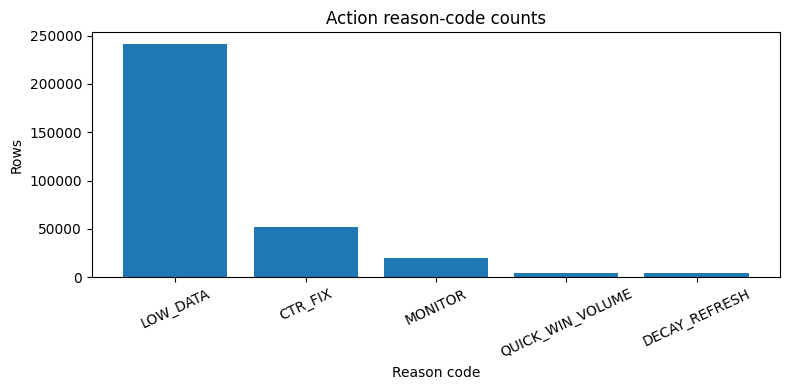

Queue written: work/outputs/action_playbook_queue.csv
Metrics written: work/outputs/w07_playbook_metrics.json
Figure written: work/figures/w07_reason_code_counts.png


In [ ]:
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue_path = "work/outputs/action_playbook_queue.csv"
metrics_path = "work/outputs/w07_playbook_metrics.json"
figure_path = "work/figures/w07_reason_code_counts.png"

queue.to_csv(queue_path, index=False)

reason_counts = (
    queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="n")
)

with open(metrics_path, "w") as f:
    json.dump(
        {
            "source_window": "2026-02",
            "queue_rows": int(len(queue)),
            "reason_code_counts": {
                str(row["reason_code"]): int(row["n"])
                for _, row in reason_counts.iterrows()
            },
            "median_impressions": float(
                queue["gsc_impressions"].median()
            ),
            "median_ctr": float(
                queue["ctr"].median()
            )
        },
        f,
        indent=2
    )

plt.figure(figsize=(8, 4))
plt.bar(
    reason_counts["reason_code"],
    reason_counts["n"]
)
plt.title("Action reason-code counts")
plt.xlabel("Reason code")
plt.ylabel("Rows")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(figure_path, dpi=150)
plt.show()

print("Queue written:", queue_path)
print("Metrics written:", metrics_path)
print("Figure written:", figure_path)



In [ ]:
assert len(queue) > 0
assert queue["rank"].is_monotonic_increasing
assert queue["reason_code"].notna().all()
assert queue["action_label"].notna().all()
assert os.path.exists(queue_path)
assert os.path.exists(metrics_path)
assert os.path.exists(figure_path)

# Actual source/model feature columns only
allowed_source_features = {
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "decay_rate"
}

actual_source_features = {
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "decay_rate"
}

assert actual_source_features == allowed_source_features

# Confirm no future or label-derived input column is present
forbidden_input_columns = [
    col for col in actual_source_features
    if col.lower() in {
        "march_ga4_sessions",
        "future_window",
        "outcome",
        "product_flag"
    }
]

assert forbidden_input_columns == []

print("Export and leakage checks: PASS")

Export and leakage checks: PASS


## Self-check

- Ranked actions and reason codes are defined.
- The queue includes an action label and review effort.
- The decay/refresh signal is explained as directional.
- Intended use and limitations are stated.
- Human review rules and no-go automation cases are included.
- Monitoring and retrain triggers are included.
- The queue is exported to `work/outputs/action_playbook_queue.csv`.
- The figure is exported to `work/figures/w07_reason_code_counts.png`.
- The metrics JSON is exported to `work/outputs/w07_playbook_metrics.json`.
- No March label, future window, client names, URLs, or private data is used.
- The notebook runs top to bottom without errors.
- The notebook is committed under `work/notebooks/w07_action_playbook.ipynb`.
